In [26]:
!pip install pandas numpy matplotlib seaborn scikit-learn shap

In [27]:
!pip install kagglehub pandas

In [28]:
# IMPORTACAO DAS BIBLIOTECAS
# pandas e numpy: manipulacao e analise de dados
# matplotlib e seaborn: visualizacao de dados
# sickit-learn: pre-processamento, trainamento e avaliacao dos modelos de machine learing
# shap: explicabilidade das previsoes dos modelos de machine learning

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import shap

sns.set_style("whitegrid")

In [29]:
# IMPORTACAO DOS DADOS
# Nesta etapa, para baixar os dados, optei por realizar o download automatico do dataset utilizando a biblioteca kagglehub, em vez de armazenar o arquivo diretamente no repositorio do projeto por questoes de reducao do tamanho do repositorio 
# Alem disso, essa abordagem permite que qualquer pessoa que execute o notebook obtenha a versao oficial e mais atual do conjunto de dados

import kagglehub
import os
import pandas as pd

# Download do dataset
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path:", path)

# Lista os arquivos disponiveis
print(os.listdir(path))

Path: C:\Users\natha\.cache\kagglehub\datasets\uciml\breast-cancer-wisconsin-data\versions\2
['data.csv']


In [30]:
# LEITURA DOS DADOS
# Leitura do dataset baixado automaticamente pelo kagglehub
# o csv é baixado pelo kagglehub e carregado em um dataframe do pandas para que assim os dados possam ser explorados, pre-processados e modelados

csv_path = os.path.join(path, "data.csv")

df = pd.read_csv(csv_path)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [31]:
# ANALISE INICIAL DOS DADOS
# o df.head exibe as primeiras linhas do dataset
# o df.info exibe as informacoes sobre as colunas, valores nao nulos e tipos de dados
# o df.shape exibe a quantidade de linhas e colunas do dataset

df.head()
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

(569, 33)

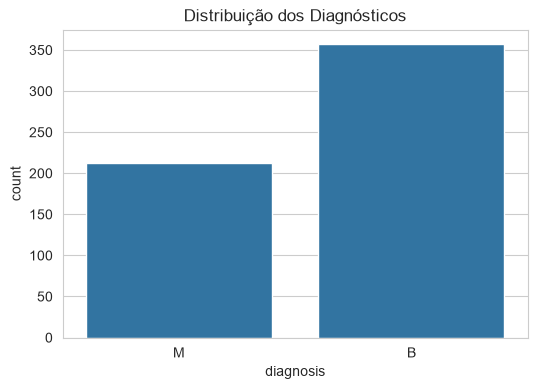

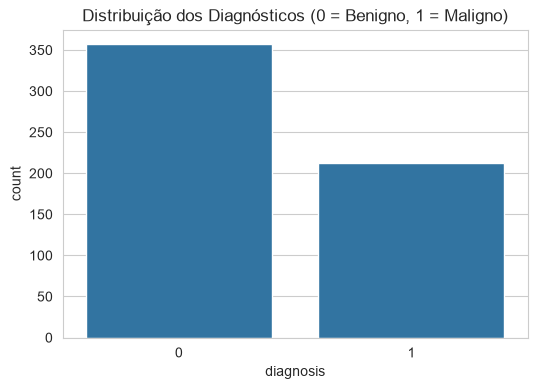

diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64

In [32]:
# ANALISE EXPLORATORIA DOS DADOS
# exploracao dos dados para compreender sua estrutura, verificar a qualidade das informacoes e identificar caracteristicas relevantes para a modelagem
# sao analisados valores ausentes, estatisticas descritivas das variaveis, distribuicao da variavel alvo, conversao da variavel alvo para o formato numerico e proporcao entre as classes do problema


# Verificacao de valores ausentes
# idenifica dados incompletos que possam precisar de tratamento
df.isnull().sum()


# Estatisticas descritivas
# exibe media, desvio padrao, valores minimos e maximos e quartis das variaveis numericas do dataset
df.describe()


# Distribuicao do diagnostico
# o diagnostico é a variavel alvo do problema, que indica se o tumor é maligno ou benigno
plt.figure(figsize=(6,4))

sns.countplot(
    x='diagnosis',
    data=df
)

plt.title("Distribuição dos Diagnósticos")
plt.show()


# Conversao da variavel alvo para formato numerico
# a variavel alvo e convertida para o formato numerico, facilitando o treinamento do modelos de machine learning
df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

plt.figure(figsize=(6,4))

sns.countplot(
    x="diagnosis",
    data=df
)

plt.title("Distribuição dos Diagnósticos (0 = Benigno, 1 = Maligno)")
plt.show()


# Proporcao das classes
# a proporcao das classes do problema e calculada para verificar se ha desbalanceamento entre as classes, o que pode afetar o desempenho dos modelos de machine learning
df["diagnosis"].value_counts(normalize=True)*100


# nao foram identificados valores ausentes no conjunto de dados, indicando que nao foi necessario realizar imputacao de valores
# a variavel alvo apresenta duas classes: tumores benignos (0) e malignos (1)
# apos a conversao para valores numericos, observa-se que aproximadamente 63% das amostras sao benignos e 37% sao malignos
# mesmo que haja um leve desbalanceamento entre as classes, ele nao e suficiente severo para inviabilizar o terinamento dos modelos propostos

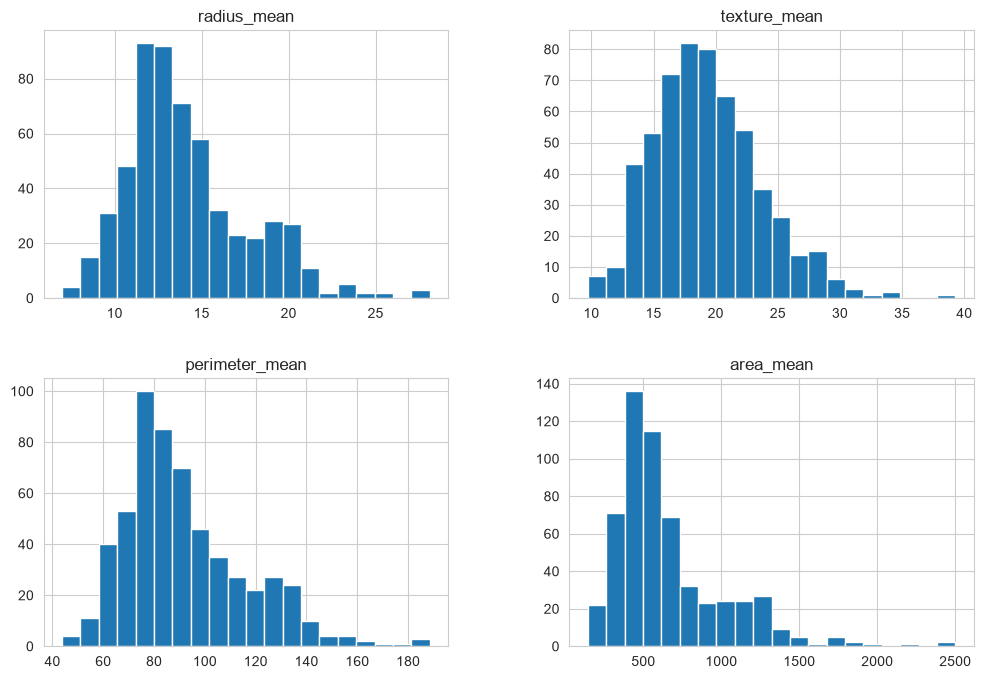

In [33]:
# ANALISE DA DISTRIBUICAO DAS PRINCIPAIS VARIAVEIS
# os histogramas permitem observar a frequencia dos valores, identificar possiveis assimetrias, dispersao e indicios de valores outliers, auxiliando a compreensao dos dados

# selecao das principais variaveis para analise da distribuicao
features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean"
]

# geracao dos histogramas das variaveis selecionadas
df[features].hist(
    figsize=(12,8),
    bins=20
)

plt.show()

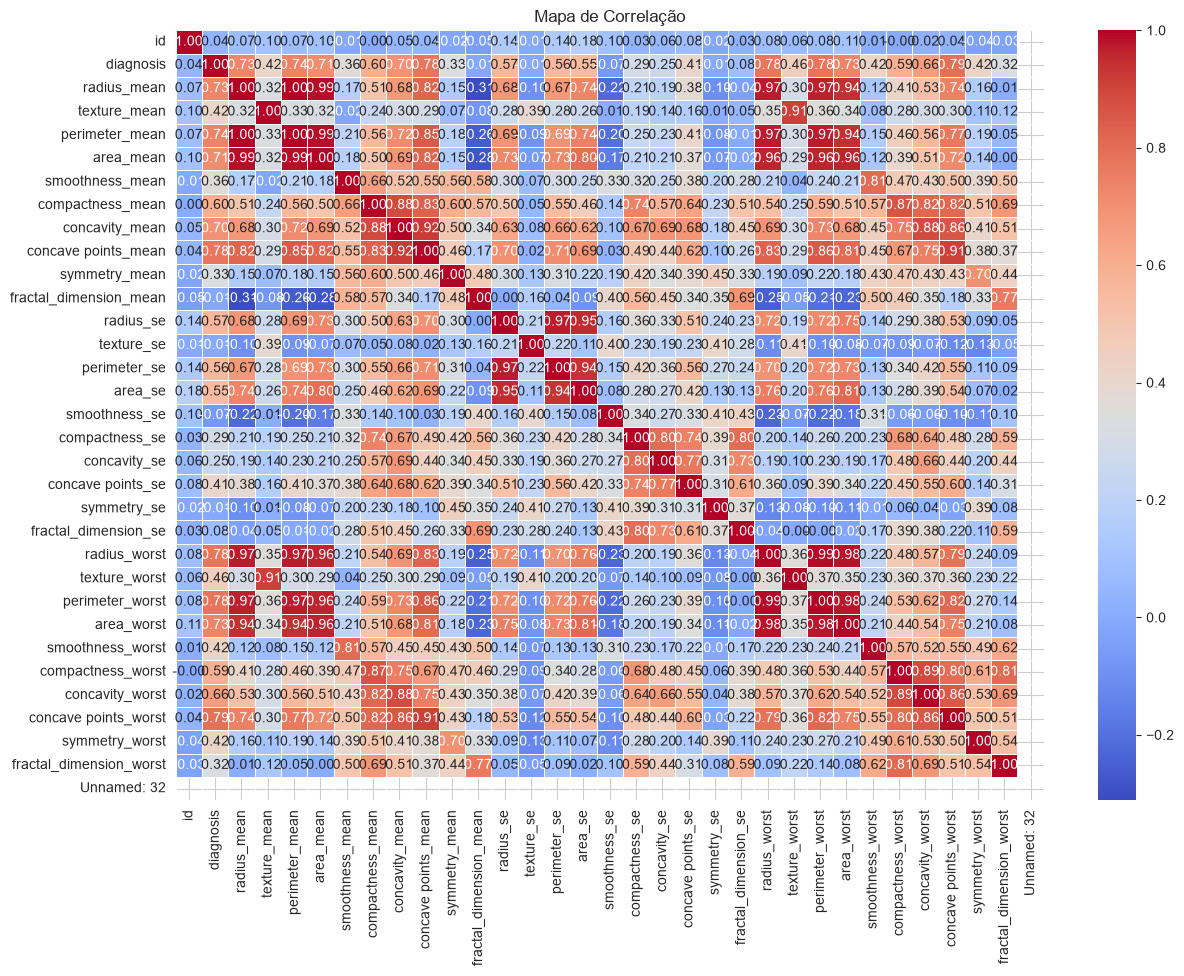

In [34]:
# ANALISE DE CORRELACAO
# calculo da matriz de correlacao entre as variaveis numericas do conjunto de dados
# o objetivo e identificar o grau de realacionamento linear entre os atributos, permitindo verificar quais caracteristicas apresentam maior associacao entre si e com a variavel alvo
# essa analise pode indicar variaveis redundantes que influenciam no processo de modelagem 

# calculo da matriz de correlacao
corr = df.corr(numeric_only=True)

# visualizacao da matriz de correlacao por meio de um mapa de calor
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa de Correlação")
plt.show()


# observa-se que atributos relacionados ao tamanho e ao formato do tumor, como raio, perimetro e area, apresentam forte correlacao positiva entre si, indicando que descrevem caracteristicas semelhantes
# tambem e possivel verificar que algumas variaveis possuem elevada correlacao com o diagnostico, demonstrando seu potencial para a classificacao entre tumores benignos e malignos

In [35]:
# CORRELACAO DAS VARIAVEIS COM O DIAGNOSTICO
# sao identificadas as variaveis que apresentam maior relacao com a variavel alvo, permitindo selecionar caracteristicas relevantes para o treinamento dos modelos de machine learning

# selecao das variaveis com maior correlacao com o diagnostico
corr_target = corr["diagnosis"].sort_values(
    ascending=False
)

# exibe as 15 variaveis com maior correlacao com o diagnostico
corr_target.head(15)


# observa-se que as variaveis relacionadas ao tamanho do tumor, como raio, perimetro e area, apresentam forte correlacao positiva com o diagnostico, indicando que tumores maiores tendem a ser malignos

diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
compactness_mean        0.596534
compactness_worst       0.590998
radius_se               0.567134
perimeter_se            0.556141
Name: diagnosis, dtype: float64

In [36]:
# PRE-PROCESSAMENTO DOS DADOS
# sao realizadas as transformacoes necessarias para preparar o conjunto de dados para o treinamento dos modelos de machine learning

# Remocao das colunas irrelevantes
if "id" in df.columns:
    df = df.drop("id", axis=1)

if "Unnamed: 32" in df.columns:
    df = df.drop("Unnamed: 32", axis=1)


# Separacao entre as variaveis independentes (x) e a variavel alvo (y)
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]


# Divisao do conjunto de dados em treino e teste, preservando a proporcao das classes por meio do parametro stratify
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Padronizacao das variaveis utilizando o standardscaler
# esse procedimento e importante para algoritmos sensiveis a escala dos atributos, como regressao logistica e knn

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# os dados foram separados em conjuntos de treino e teste, com 80% das amostras para treino e 20% para teste, garantindo que a proporcao das classes seja mantida em ambos os conjuntos

In [37]:
# REGRESSAO LOGISTICA
# a regressao logistica e utilizada como primeiro modelo de classificacao poe ser um algoritmo amplamanete empregado em problemas de classificacao binaria
# ela apresenta boa capacidade preditiva e seus resultados sao dde facil interpretacao

# criacao do modelo de regressao logistica com max_iter=5000 para garantir a convergencia do algoritmo
log_model = LogisticRegression(
    max_iter=5000
)

log_model.fit(
    X_train_scaled,
    y_train
)

# realizacao das previsoes do modelo de regressao logistica no conjunto de teste
y_pred_log = log_model.predict(
    X_test_scaled
)

# avaliacao do desempenho do modelo por meio de metricas accuracy, recall e f1-score, alem do classification report que apresenta uma analise detalhada das metricas de desempenho do modelo
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

print(
    "Accuracy:",
    accuracy_score(y_test,y_pred_log)
)

print(
    "Recall:",
    recall_score(y_test,y_pred_log)
)

print(
    "F1:",
    f1_score(y_test,y_pred_log)
)


# o modelo apresenta uma elevada capacidade preditiva, alcancando bons resultados nas metricas de accuracy, recall e fi-score
# pode-se considerar o recall a metrica mais importante nesse contexto, pois mede a capacidade do modelo de iddentificar corretamente os casos malignos, reduzindo a ocorrencia de falsos negativos que podem comprometer  o diagnostico clinico

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Accuracy: 0.9649122807017544
Recall: 0.9285714285714286
F1: 0.9512195121951219


In [38]:
# KNN - K-NEAREST NEIGHBORS
# o knn funciona baseado na proximidade entre as amostras, classificando novos registros de acordo com a classe predominante entre os k vizinhos mais proximos

# criacao do modelo knn com 5 vizinhos
knn = KNeighborsClassifier(
    n_neighbors=5
)

# treinamento do modelo utilizando os dados padronizados
knn.fit(
    X_train_scaled,
    y_train
)

# realizacao das previsoes utilizando o conjunto de teste
y_pred_knn = knn.predict(
    X_test_scaled
)

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_knn)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_knn)
)

print(
    "F1:",
    f1_score(y_test, y_pred_knn)
)


# o modelo apresenta um bom desempenho na identificacao dos tumores, obtendo elevados valores de accuracy, recall e f1-score

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuracy: 0.956140350877193
Recall: 0.9047619047619048
F1: 0.9382716049382716


In [39]:
# RANDOM FOREST
# o random  forest e baseado na combinacao de diversas arvores de decisao, formando uma floresta de classificadores que trabalham em conjunto para gerar previsoes mais robustas e reduzir o risco de overfitting

# criacao do modelo random forest com 300 arvores
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# treinamento do modelo utilizando os dados de treino
rf.fit(
    X_train,
    y_train
)

# realizacao das previsoes utilizando o conjunto de teste
y_pred_rf = rf.predict(
    X_test
)


# avaliacao do desempenho do modelo random forest por meio das metricas accuracy, recall e f1-score
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print(
    "Accuracy:",
    accuracy_score(y_test,y_pred_rf)
)

print(
    "Recall:",
    recall_score(y_test,y_pred_rf)
)

print(
    "F1:",
    f1_score(y_test,y_pred_rf)
)


# o modelo random forest apresenta um melhor desempenho entre os modelos avaliados, sua estrutura baseada em multiplas arvores de decisao contribui para uma avaliacao mais robusta dos tumores, reduzindo a influencia de variacoes individuais presente nos dados

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Accuracy: 0.9736842105263158
Recall: 0.9285714285714286
F1: 0.9629629629629629


In [40]:
# COMPARACAO DOS MODELOS (REGRESSAO LOGISTICA, KNN E RANDOM FOREST)
# os modelos foram comparados com base nas metricas de accuracy, recall e f1-score, permitindo identificar qual algoritmo apresentou os melhores resultados para o problema de classificacao do cancer de mama

resultados = pd.DataFrame({
    "Modelo":[
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_rf)
    ],
    "Recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_knn),
        recall_score(y_test,y_pred_rf)
    ],
    "F1":[
        f1_score(y_test,y_pred_log),
        f1_score(y_test,y_pred_knn),
        f1_score(y_test,y_pred_rf)
    ]
})

resultados


# como o objetivo do projeto e apoiar os diagnosticos de cancer de mama, foi dada maior importancia ao recall, pois essa metrica representa a capacidade do modelo de idetificar corretamente os casos malignos, reduzindo a ocorrencia de falsos negativos

,Modelo,Accuracy,Recall,F1
0,Logistic Regression,0.964912,0.928571,0.951220
1,KNN,0.956140,0.904762,0.938272
2,Random Forest,0.973684,0.928571,0.962963


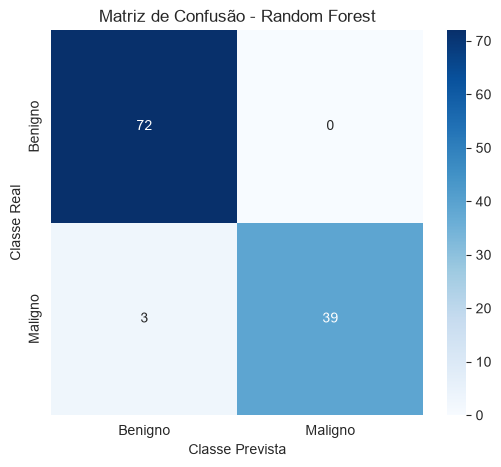

In [41]:
# MATRIZ DE CONFUSAO DO MODELO RANDOM FOREST
# permite analisar o desempenho do classificador de forma detalhada, apresentando a quantidade de classificacoes corretas e incorretas para cada classe
# a matriz permite identificar verdadeiros positivos (VP), verdadeiros negativos (VN), falsos positivos (FP) e falsos negativos (FN)
# em aplicacoes medicas, a analise dos falsos negativos e especialmente importante, pois representa casos malignos classificados incorretamente como benignos

# geracao da matriz de confusao para o modelo random forest
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"]
)

plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de Confusão - Random Forest")

plt.show()


# observa-se que a maior parte das amostras for classificada corretamente, evidenciando a boa capacidade do modelo em distinguir tumores benignos e malignos
# os poucos erros de classificacao concentram-se nos falsos negativos e falsos positivos, sendo os casos de falsos negativos os casos de maior preocupacao, pois representam pacientes com tumores malignos que foram classificados incorretamente como benignos
# a matriz de confusao completa as metricas de avaliacao ao permitir uma analise mais detalhada dos acertos e erros do modelo

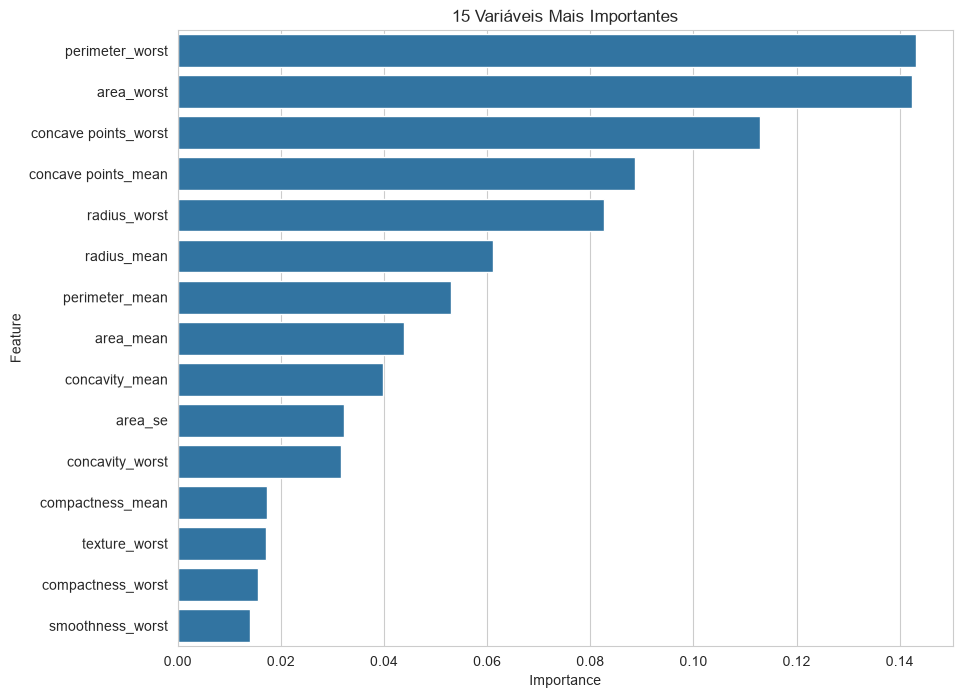

In [42]:
# FEATURE IMPORTANCE
# o algoritmo calcula um indice de importancia para cada atributo com base na contribuicao de cada variavel para a reducao da impureza durante a construcao das arvores de decisao
# essa analise permite identificar quais caracteristicas tiveram maior influencia na classificacao dos tumores, tornando o modelo mais interpretavel


# criacao de um dataframe com as variaveis e seus respectivos indices de importancia
importances = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

# ordenacao das variaveis com base no indice de importancia, do maior para o menor
importances = importances.sort_values(
    by="Importance",
    ascending=False
)

# visualizacao das 15 variaveis mais importantes para o processo de classificacao
plt.figure(figsize=(10,8))

sns.barplot(
    data=importances.head(15),
    x="Importance",
    y="Feature"
)

plt.title("15 Variáveis Mais Importantes")
plt.show()


# observa-se que as variaveis relacionadas ao tamanho, ,ao formato e a concavidade dos tumores apresentaram os maiores indices de importancia, indicando que esssas caracteristicas sao determinantes para a diferenciacao entre tumores benignos e malignos
# essa analise contribui para aumentar a transparencia do modelo, permitindo compreender quais informacoes foram mais relevantes durante o processo de classificacao

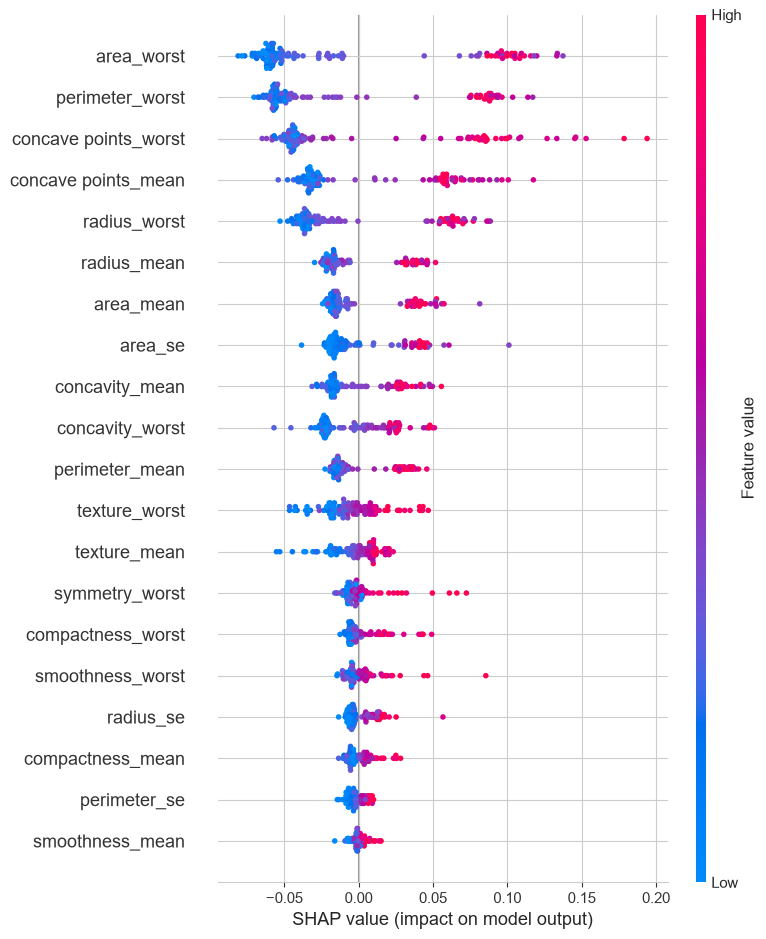

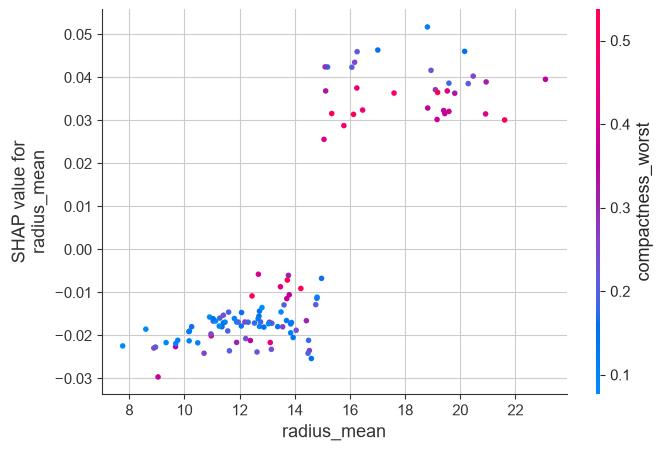

In [43]:
# EXPLICABILIDADE DO MODELO COM SHAP
# o shap e uma biblioteca que permite explicar as previsoes de modelos de machine learning, atribuindo a cada variavel uma contribuicao para a decisao do modelo
# sao geradas duas visualizacoes: o summary plot, que apresenta a importancia das variaveis e a distribuicao de seus efeitos nas previsoes, e o dependence plot, que mostra a relacao entre uma variavel especifica e suas contribuicoes para as previsoes do modelo

# criacao do explainer do modelo random forest
explainer = shap.TreeExplainer(
    rf
)

# calculo dos valores de shap para o conjunto de teste
shap_values = explainer.shap_values(
    X_test
)


# summary plot, que apresenta a importancia das variaveis e a distribuicao de seus efeitos nas previsoes do modelo
shap.summary_plot(
    shap_values[:,:,1],
    X_test
)


# dependency plot, que mostra a relacao entre uma variavel especifica e suas contribuicoes para as previsoes do modelo
shap.dependence_plot(
    "radius_mean",
    shap_values[:,:,1],
    X_test
)


# cada ponto do summary plot representa uma observacao do conjunto de dados, enquanto as cores indicam a magnitude do valor da variavel (azul para valores baixos e vermelho para valores elevados)
# a posicao horizontal demonstra o impacto da variavel na decisaao do modelo, assim e possivel identificar quais atributos exerceram maior influencia na classificacao dos tumores
# nessse projeto foi utilizada a variavel radiius_mean, possibilitando observar como diferentes valores do raio medio do tumor afetam a probabilidade de classificacao entre tumores benignos e malignos

In [44]:
# OBSERVACOES E CONCLUSOES

print("""
Observações:

- Foram treinados e avaliados três modelos de classificação: Regressão Logística, KNN e Random Forest.
- O Random Forest apresentou o melhor desempenho entre os modelos analisados, obtendo os maiores valores para as métricas de avaliação.
- O Recall foi considerado a métrica mais relevante, pois representa a capacidade do modelo em identificar corretamente os casos malignos, reduzindo a ocorrência de falsos negativos.
- As análises de Feature Importance e SHAP permitiram identificar as variáveis que mais influenciaram as decisões do modelo, aumentando sua interpretabilidade.
- Apesar do elevado desempenho obtido, a solução deve ser utilizada apenas como ferramenta de apoio à decisão clínica, não substituindo a avaliação realizada por profissionais de saúde.
""")

print("""
Conclusões:

- Foi desenvolvido um modelo de Machine Learning para auxiliar na classificação de tumores de mama em benignos e malignos.
- O projeto contemplou todas as etapas do processo de Ciência de Dados, incluindo análise exploratória, pré-processamento, treinamento, avaliação e interpretabilidade dos modelos.
- Entre os algoritmos avaliados, o Random Forest apresentou o melhor desempenho, sendo selecionado como modelo final.
- As técnicas de Feature Importance e SHAP contribuíram para compreender quais características dos tumores exerceram maior influência nas previsões do modelo.
- Os resultados obtidos demonstram que técnicas de Machine Learning possuem potencial para apoiar o diagnóstico precoce do câncer de mama, desde que utilizadas como ferramenta complementar à análise médica.
""")


Observações:

- Foram treinados e avaliados três modelos de classificação: Regressão Logística, KNN e Random Forest.
- O Random Forest apresentou o melhor desempenho entre os modelos analisados, obtendo os maiores valores para as métricas de avaliação.
- O Recall foi considerado a métrica mais relevante, pois representa a capacidade do modelo em identificar corretamente os casos malignos, reduzindo a ocorrência de falsos negativos.
- As análises de Feature Importance e SHAP permitiram identificar as variáveis que mais influenciaram as decisões do modelo, aumentando sua interpretabilidade.
- Apesar do elevado desempenho obtido, a solução deve ser utilizada apenas como ferramenta de apoio à decisão clínica, não substituindo a avaliação realizada por profissionais de saúde.


Conclusões:

- Foi desenvolvido um modelo de Machine Learning para auxiliar na classificação de tumores de mama em benignos e malignos.
- O projeto contemplou todas as etapas do processo de Ciência de Dados, incluin